Exercise 1: Classification Dataset (Supervised Learning)

Dataset: Iris Flower Dataset

UCI Repository link: https://archive.ics.uci.edu/ml/datasets/iris

Abstract: The objective of this exercise is to predict the species of an Iris flower based on its sepal and petal measurements. The Iris dataset consists of 150 samples, each described by four numerical features: sepal length, sepal width, petal length, and petal width. Using this dataset, a suitable classification model such as Logistic Regression, K-Nearest Neighbors, or Decision Tree is to be developed. The task involves performing exploratory data analysis and necessary preprocessing, followed by training and validating
the model on the given data. The performance of the trained model is to be assessed using standard evaluation metrics including accuracy, precision, recall, F1-score, and confusion matrix, along with cross-validation to ensure reliability. The results obtained from these evaluation strategies are to be
interpreted to understand the effectiveness of the model and the significance of each performance metric.


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

In [6]:
columns = [
    "sepal_length",
    "sepal_width",
    "petal_length",
    "petal_width",
    "class"
]

In [7]:
df = pd.read_csv("iris.data", header=None, names=columns)

In [8]:
print("Dataset Shape:", df.shape)
print(df.head())

Dataset Shape: (150, 5)
   sepal_length  sepal_width  petal_length  petal_width        class
0           5.1          3.5           1.4          0.2  Iris-setosa
1           4.9          3.0           1.4          0.2  Iris-setosa
2           4.7          3.2           1.3          0.2  Iris-setosa
3           4.6          3.1           1.5          0.2  Iris-setosa
4           5.0          3.6           1.4          0.2  Iris-setosa


In [9]:
df["class"] = df["class"].astype("category").cat.codes

X = df.drop(columns=["class"])
y = df["class"]

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [11]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [13]:
model = LogisticRegression(max_iter=200)
model.fit(X_train, y_train)

LogisticRegression(max_iter=200)

In [14]:
y_pred = model.predict(X_test)

In [15]:
print("\n--- CLASSIFICATION EVALUATION (IRIS) ---")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision (macro):", precision_score(y_test, y_pred, average='macro'))
print("Recall (macro):", recall_score(y_test, y_pred, average='macro'))
print("F1 Score (macro):", f1_score(y_test, y_pred, average='macro'))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))


--- CLASSIFICATION EVALUATION (IRIS) ---
Accuracy: 1.0
Precision (macro): 1.0
Recall (macro): 1.0
F1 Score (macro): 1.0
Confusion Matrix:
 [[19  0  0]
 [ 0 13  0]
 [ 0  0 13]]


In [16]:
cv_scores = cross_val_score(model, X, y, cv=5)
print("Cross Validation Accuracy:", cv_scores.mean())

Cross Validation Accuracy: 0.9733333333333334


Exercise 2:

Dataset: Wholesale Customers Data Set

UCI Repository link:

https://archive.ics.uci.edu/ml/datasets/wholesale+customers

https://www.kaggle.com/datasets/binovi/wholesale-customers-data-set

Abstract: The objective of this exercise is to segment wholesale customers based on their annual spending patterns across different product categories. The Wholesale Customers dataset contains numerical attributes representing yearly expenditure on items such as fresh products, milk, grocery, frozen foods,
detergents and paper, and delicatessen. Since no predefined class labels are available, unsupervised learning techniques are to be applied to identify natural groupings within the data. The task involves performing exploratory data analysis and preprocessing steps such as feature scaling, followed by the application of a clustering algorithm like K-Means or Hierarchical Clustering. The optimal number of clusters is to be determined using evaluation techniques such as the Elbow method and Silhouette score. The resulting clusters are to be visualized using dimensionality reduction techniques like PCA, and the cluster characteristics are to be analyzed and interpreted to understand customer segmentation and spending behavior.

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

In [17]:
df = pd.read_csv("Wholesale customers data.csv")

In [19]:
print("Dataset Shape:", df.shape)
print(df.head())

Dataset Shape: (440, 8)
   Channel  Region  Fresh  Milk  Grocery  Frozen  Detergents_Paper  Delicassen
0        2       3  12669  9656     7561     214              2674        1338
1        2       3   7057  9810     9568    1762              3293        1776
2        2       3   6353  8808     7684    2405              3516        7844
3        1       3  13265  1196     4221    6404               507        1788
4        2       3  22615  5410     7198    3915              1777        5185


In [20]:
if 'Channel' in df.columns and 'Region' in df.columns:
    X = df.drop(columns=['Channel', 'Region'])
else:
    X = df.copy()

In [21]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

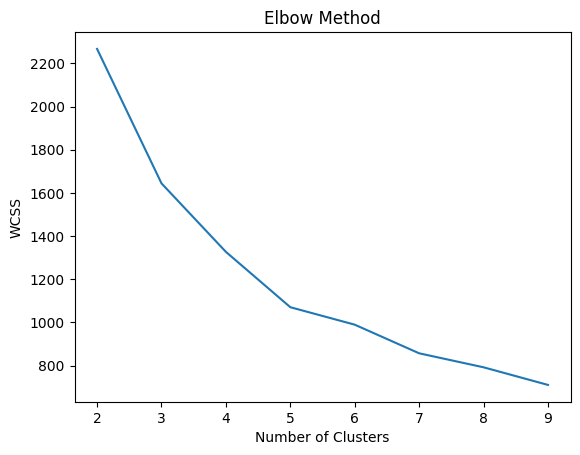

In [22]:
wcss = []
for i in range(2, 10):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(2, 10), wcss)
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

In [23]:
kmeans = KMeans(n_clusters=3, random_state=42)
labels = kmeans.fit_predict(X_scaled)

In [24]:
sil_score = silhouette_score(X_scaled, labels)
print("Silhouette Score:", sil_score)

Silhouette Score: 0.4582633767207058


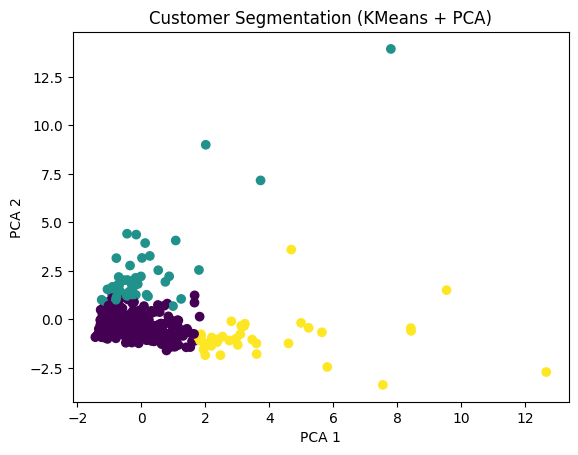

In [25]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels)
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("Customer Segmentation (KMeans + PCA)")
plt.show()